Printing Soil Heat Flux Plot


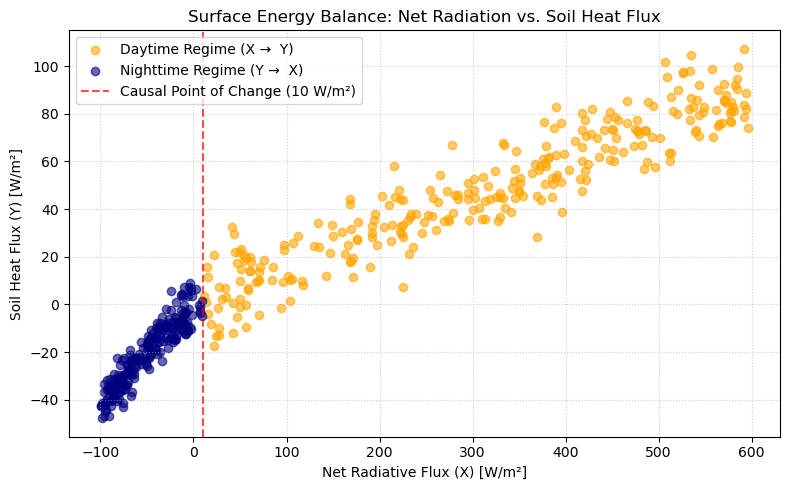

Saved: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/Causal Challenge/data/soil_heat_flux_plot.png

 Printing Traffic Dynamics Plot


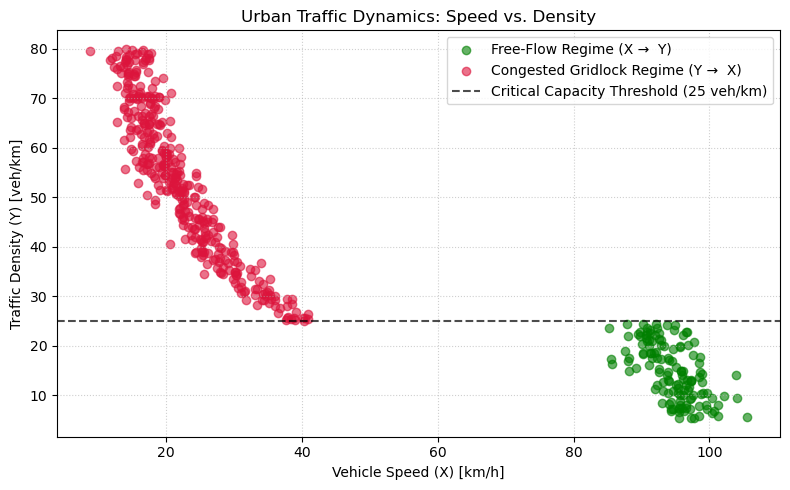

Saved: /Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/Causal Challenge/data/traffic_dynamics_plot.png



In [9]:
# Scatter Plots 
import os
import matplotlib.pyplot as plt
import pandas as pd

target_dir = r'/Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/Causal Challenge/data'

# Make sure the directory exists
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"Created directory: {target_dir}")

# Part 1: Generate and Print Soil Heat Flux Plot 
flux_path = os.path.join(target_dir, 'soil_heat_flux_data.csv')

if os.path.exists(flux_path):
    df_flux = pd.read_csv(flux_path)
    
    plt.figure(figsize=(8, 5))
    
    # Separate daytime and nighttime data points based on the 10 W/m² threshold
    daytime_data = df_flux[df_flux['Net_Radiative_Flux'] > 10]
    nighttime_data = df_flux[df_flux['Net_Radiative_Flux'] <= 10]
    
    # Create the scatter plot layers
    plt.scatter(daytime_data['Net_Radiative_Flux'], daytime_data['Soil_Heat_Flux'], 
                color='orange', alpha=0.6, label='Daytime Regime (X →  Y)')
    plt.scatter(nighttime_data['Net_Radiative_Flux'], nighttime_data['Soil_Heat_Flux'], 
                color='navy', alpha=0.6, label='Nighttime Regime (Y →  X)')
    
    # Add the threshold indicator line
    plt.axvline(x=10, color='red', linestyle='--', alpha=0.7, label='Causal Point of Change (10 W/m²)')
    
    # Label the plot elements correctly
    plt.title('Surface Energy Balance: Net Radiation vs. Soil Heat Flux')
    plt.xlabel('Net Radiative Flux (X) [W/m²]')
    plt.ylabel('Soil Heat Flux (Y) [W/m²]')
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot image to your folder
    flux_plot_path = os.path.join(target_dir, 'soil_heat_flux_plot.png')
    plt.savefig(flux_plot_path, dpi=300)
    
    # Print the plot directly in your Jupyter Notebook screen
    print("Printing Soil Heat Flux Plot")
    plt.show()
    print(f"Saved: {flux_plot_path}\n")
else:
    print(f"Error: Could not find 'soil_heat_flux_data.csv' in {target_dir}")


# Part 2: Generate and Print Traffic Dynamics Plot 
traffic_path = os.path.join(target_dir, 'traffic_dynamics_data.csv')

if os.path.exists(traffic_path):
    df_traffic = pd.read_csv(traffic_path)
    
    plt.figure(figsize=(8, 5))
    
    # Separate free-flow and congested data points based on the 25 veh/km threshold
    free_flow_data = df_traffic[df_traffic['Traffic_Density'] <= 25]
    congested_data = df_traffic[df_traffic['Traffic_Density'] > 25]
    
    # Create the scatter plot layers with Speed on X-axis and Density on Y-axis
    plt.scatter(free_flow_data['Vehicle_Speed'], free_flow_data['Traffic_Density'], 
                color='green', alpha=0.6, label='Free-Flow Regime (X →  Y)')
    plt.scatter(congested_data['Vehicle_Speed'], congested_data['Traffic_Density'], 
                color='crimson', alpha=0.6, label='Congested Gridlock Regime (Y →  X)')
    
    # Add the threshold indicator line
    plt.axhline(y=25, color='black', linestyle='--', alpha=0.7, label='Critical Capacity Threshold (25 veh/km)')
    
    # Label the plot elements correctly
    plt.title('Urban Traffic Dynamics: Speed vs. Density')
    plt.xlabel('Vehicle Speed (X) [km/h]')
    plt.ylabel('Traffic Density (Y) [veh/km]')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    # Save the plot image to your folder
    traffic_plot_path = os.path.join(target_dir, 'traffic_dynamics_plot.png')
    plt.savefig(traffic_plot_path, dpi=300)
    
    # Print the plot directly in your Jupyter Notebook screen
    print(" Printing Traffic Dynamics Plot")
    plt.show()
    print(f"Saved: {traffic_plot_path}\n")
else:
    print(f"Error: Could not find 'traffic_dynamics_data.csv' in {target_dir}")

--- Processing Pair 3 (Pair 0001) ---
Printing Pair 3 Scatter Plot...


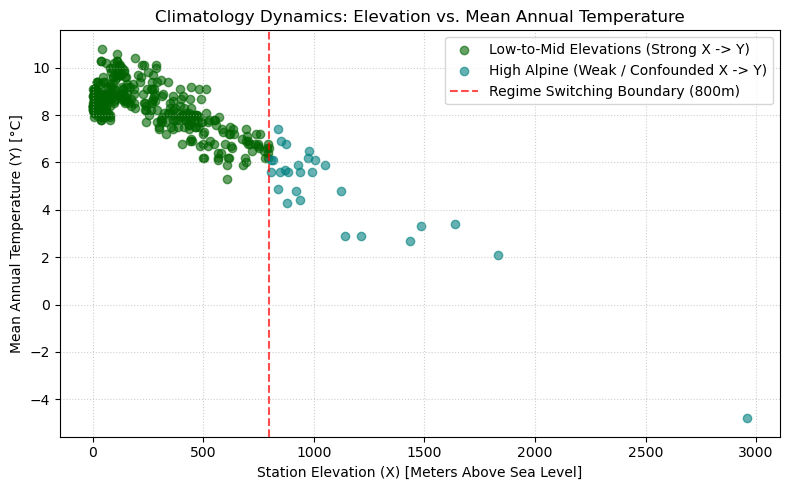


--- Processing Pair 4 (Pair 0006) ---
Printing Pair 4 Scatter Plot...


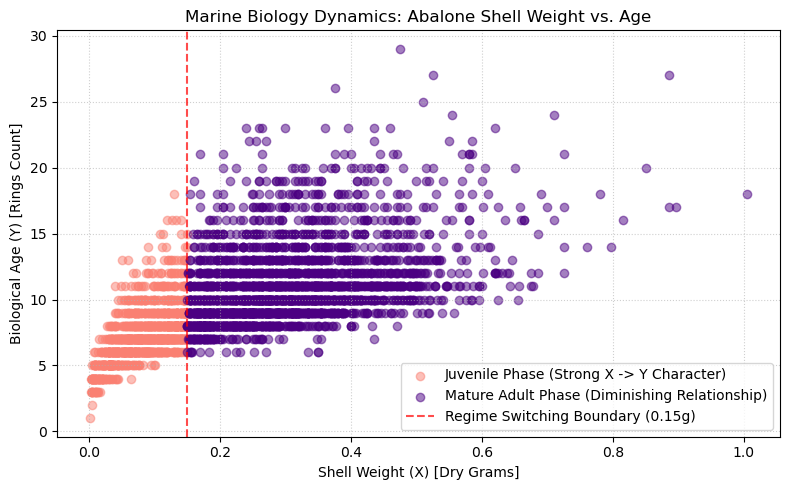


Finished! Both raw datasets (.txt) and scatter plots (.png) are successfully downloaded and saved to folder.


In [6]:



import os
import urllib.request
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define your exact university folder path
target_dir = r'/Users/fahad/Documents/MY#Documents/FAHAD ALI/Uni Wien/6th Semester/RDKD/Causal Challenge'

# Ensure the target directory exists
if not os.path.exists(target_dir):
    os.makedirs(target_dir)
    print(f"Created folder: {target_dir}")

# ========================================================
# RUNNING PAIR 3: Elevation vs. Temperature (Pair 0001)
# ========================================================
print("--- Processing Pair 3 (Pair 0001) ---")
url_0001 = "https://webdav.tuebingen.mpg.de/cause-effect/pair0001.txt"
txt_path_0001 = os.path.join(target_dir, 'pair0001.txt')

# Explicitly download the raw dataset text file
print(f"Downloading raw dataset to: {txt_path_0001}")
urllib.request.urlretrieve(url_0001, txt_path_0001)

# Load into pandas for plotting
df_0001 = pd.read_csv(txt_path_0001, sep=r'\s+', header=None, names=['Elevation', 'Temperature'])
df_0001.dropna(inplace=True)

# Split data at the 800m threshold
threshold_elev = 800.0
regime1_elev = df_0001[df_0001['Elevation'] <= threshold_elev]
regime2_elev = df_0001[df_0001['Elevation'] > threshold_elev]

# Create the plot
plt.figure(figsize=(8, 5))
plt.scatter(regime1_elev['Elevation'], regime1_elev['Temperature'], 
            color='darkgreen', alpha=0.6, label='Low-to-Mid Elevations (Strong X -> Y)')
plt.scatter(regime2_elev['Elevation'], regime2_elev['Temperature'], 
            color='teal', alpha=0.6, label='High Alpine (Weak / Confounded X -> Y)')
plt.axvline(x=threshold_elev, color='red', linestyle='--', alpha=0.7, label='Regime Switching Boundary (800m)')

plt.title('Climatology Dynamics: Elevation vs. Mean Annual Temperature')
plt.xlabel('Station Elevation (X) [Meters Above Sea Level]')
plt.ylabel('Mean Annual Temperature (Y) [°C]')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save image file and print plot on screen
plot_path3 = os.path.join(target_dir, 'elevation_temperature_plot.png')
plt.savefig(plot_path3, dpi=300)
print("Printing Pair 3 Scatter Plot...")
plt.show()


# ========================================================
# RUNNING PAIR 4: Abalone Shell Weight vs. Age (Pair 0006)
# ========================================================
print("\n--- Processing Pair 4 (Pair 0006) ---")
url_0006 = "https://webdav.tuebingen.mpg.de/cause-effect/pair0006.txt"
txt_path_0006 = os.path.join(target_dir, 'pair0006.txt')

# Explicitly download the raw dataset text file
print(f"Downloading raw dataset to: {txt_path_0006}")
urllib.request.urlretrieve(url_0006, txt_path_0006)

# Load the columns in their true order as they exist in pair0006.txt
df_0006 = pd.read_csv(txt_path_0006, sep=r'\s+', header=None, names=['Age', 'ShellWeight'])
df_0006.dropna(inplace=True)

# Split data at the 0.15g shell weight threshold on the correct column
threshold_weight = 0.15
regime1_weight = df_0006[df_0006['ShellWeight'] <= threshold_weight]
regime2_weight = df_0006[df_0006['ShellWeight'] > threshold_weight]

# Create the corrected plot (Shell Weight as X, Age as Y)
plt.figure(figsize=(8, 5))
plt.scatter(regime1_weight['ShellWeight'], regime1_weight['Age'], 
            color='salmon', alpha=0.5, label='Juvenile Phase (Strong X -> Y Character)')
plt.scatter(regime2_weight['ShellWeight'], regime2_weight['Age'], 
            color='indigo', alpha=0.5, label='Mature Adult Phase (Diminishing Relationship)')
plt.axvline(x=threshold_weight, color='red', linestyle='--', alpha=0.7, label='Regime Switching Boundary (0.15g)')

plt.title('Marine Biology Dynamics: Abalone Shell Weight vs. Age')
plt.xlabel('Shell Weight (X) [Dry Grams]')
plt.ylabel('Biological Age (Y) [Rings Count]')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save image file and print plot on screen
plot_path4 = os.path.join(target_dir, 'abalone_weight_age_plot.png')
plt.savefig(plot_path4, dpi=300)
print("Printing Pair 4 Scatter Plot...")
plt.show()

print("\nFinished! Both raw datasets (.txt) and scatter plots (.png) are successfully downloaded and saved to folder.")